# Bank Marketing Campaign & Conversion Performance Analysis

## Future Interns – Data Science & Analytics Task 3

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

Matplotlib is building the font cache; this may take a moment.


In [3]:
df = pd.read_csv(
    r"C:\Users\Vijay\Desktop\Future-DS3\bank-full.csv",
    sep=";"
)

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 1. Dataset Overview

In [4]:
df.shape

(45211, 17)

In [5]:
df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

### Dataset Variables

| Variable | Description |
|---|---|
| age | Customer age |
| job | Customer occupation |
| marital | Marital status |
| education | Education level |
| default | Whether the customer has credit in default |
| balance | Average yearly balance |
| housing | Whether the customer has a housing loan |
| loan | Whether the customer has a personal loan |
| contact | Contact communication type |
| day | Day of the month when contacted |
| month | Month of last contact |
| duration | Duration of last contact in seconds |
| campaign | Number of contacts performed during the current campaign |
| pdays | Number of days since previous campaign contact |
| previous | Number of contacts performed before this campaign |
| poutcome | Outcome of the previous marketing campaign |
| y | Whether the customer subscribed to a term deposit |

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 8.1 MB


In [7]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### Missing Value Analysis

In [8]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

### Check duplicate records

In [9]:
df.duplicated().sum()

np.int64(0)

### Check target variable

In [10]:
df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [11]:
df["y"].value_counts(normalize=True) * 100

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

### Create our first KPI

In [12]:
conversion_rate = (
    df["y"].value_counts(normalize=True)["yes"] * 100
)

print(f"Overall Conversion Rate: {conversion_rate:.2f}%")

Overall Conversion Rate: 11.70%


### Check categorical variables

In [13]:
categorical_columns = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome",
    "y"
]

for col in categorical_columns:
    print(f"\n--- {col.upper()} ---")
    print(df[col].value_counts())


--- JOB ---
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

--- MARITAL ---
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

--- EDUCATION ---
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

--- DEFAULT ---
default
no     44396
yes      815
Name: count, dtype: int64

--- HOUSING ---
housing
yes    25130
no     20081
Name: count, dtype: int64

--- LOAN ---
loan
no     37967
yes     7244
Name: count, dtype: int64

--- CONTACT ---
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

--- MONTH ---
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403

### Check numerical variables

In [14]:
numeric_columns = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


### Target Distribution

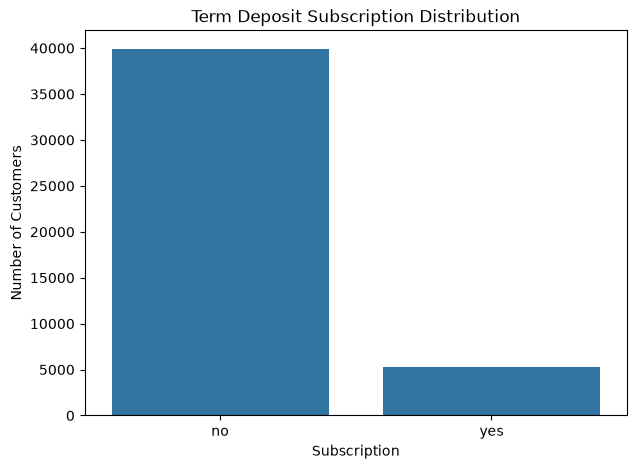

In [15]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="y"
)

plt.title("Term Deposit Subscription Distribution")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")

plt.show()

In [16]:
# Calculate conversion by customer job
job_conversion = (
    df.groupby("job")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
)

job_conversion

job
student          28.678038
retired          22.791519
unemployed       15.502686
management       13.755551
admin.           12.202669
self-employed    11.842939
unknown          11.805556
technician       11.056996
services          8.883004
housemaid         8.790323
entrepreneur      8.271688
blue-collar       7.274969
Name: y, dtype: float64

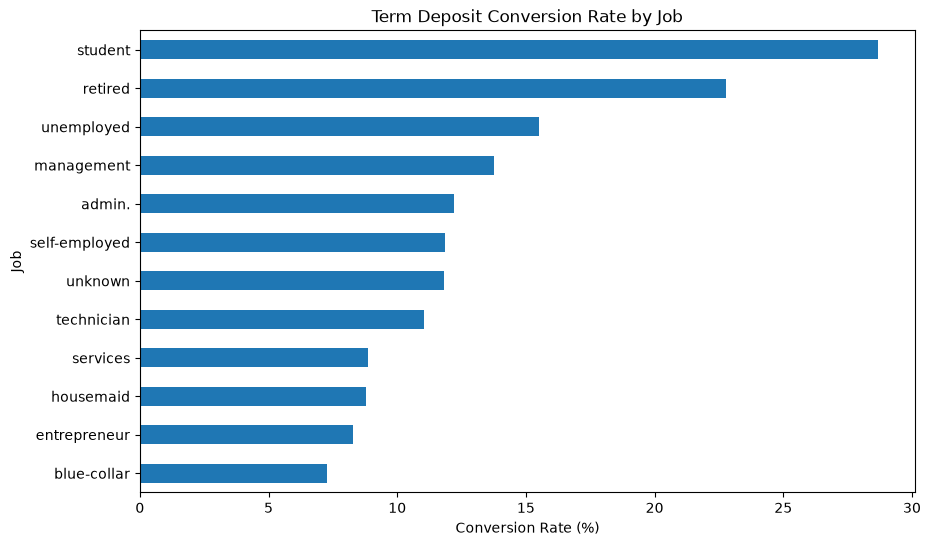

In [17]:
plt.figure(figsize=(10, 6))

job_conversion.sort_values().plot(
    kind="barh"
)

plt.title("Term Deposit Conversion Rate by Job")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Job")

plt.show()

### Conversion by contact channel

In [18]:
contact_conversion = (
    df.groupby("contact")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
)

contact_conversion

contact
cellular     14.918900
telephone    13.420509
unknown       4.070661
Name: y, dtype: float64

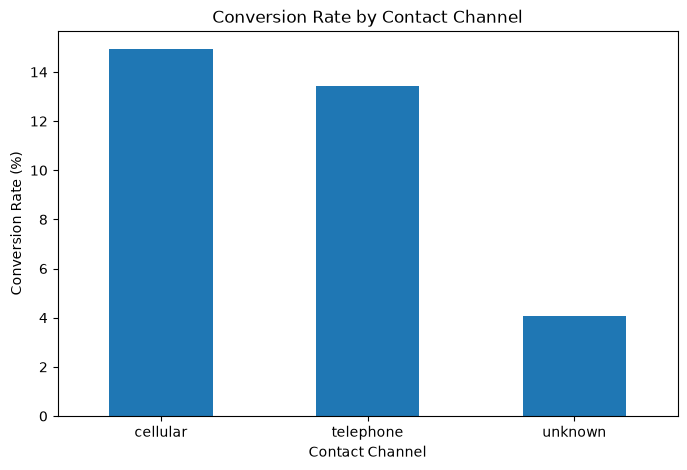

In [19]:
plt.figure(figsize=(8, 5))

contact_conversion.plot(
    kind="bar"
)

plt.title("Conversion Rate by Contact Channel")
plt.xlabel("Contact Channel")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=0)

plt.show()

## 2. Data Cleaning & Feature Engineering

The raw dataset is preserved without modification. A copy of the dataset
will be used for cleaning and feature engineering.

In [20]:
df_clean = df.copy()

df_clean.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [21]:
df_clean.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='str')

In [22]:
categorical_columns = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome",
    "y"
]

for col in categorical_columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()

In [23]:
for col in categorical_columns:
    print(col, df_clean[col].unique())

job <ArrowStringArray>
[   'management',    'technician',  'entrepreneur',   'blue-collar',
       'unknown',       'retired',        'admin.',      'services',
 'self-employed',    'unemployed',     'housemaid',       'student']
Length: 12, dtype: str
marital <ArrowStringArray>
['married', 'single', 'divorced']
Length: 3, dtype: str
education <ArrowStringArray>
['tertiary', 'secondary', 'unknown', 'primary']
Length: 4, dtype: str
default <ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str
housing <ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str
loan <ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str
contact <ArrowStringArray>
['unknown', 'cellular', 'telephone']
Length: 3, dtype: str
month <ArrowStringArray>
['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'jan', 'feb', 'mar', 'apr',
 'sep']
Length: 12, dtype: str
poutcome <ArrowStringArray>
['unknown', 'failure', 'other', 'success']
Length: 4, dtype: str
y <ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str


In [24]:
missing_values = df_clean.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [25]:
for col in categorical_columns:
    unknown_count = (df_clean[col] == "unknown").sum()
    
    if unknown_count > 0:
        print(f"{col}: {unknown_count}")

job: 288
education: 1857
contact: 13020
poutcome: 36959


In [26]:
df_clean[
    [
        "age",
        "balance",
        "day",
        "duration",
        "campaign",
        "pdays",
        "previous"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


In [27]:
df_clean[
    (df_clean["age"] < 18) |
    (df_clean["age"] > 100)
]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y


In [28]:
df_clean["age"].min(), df_clean["age"].max()

(np.int64(18), np.int64(95))

In [29]:
(df_clean["balance"] < 0).sum()

np.int64(3766)

In [30]:
df_clean["campaign"].describe()

count    45211.000000
mean         2.763841
std          3.098021
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         63.000000
Name: campaign, dtype: float64

In [31]:
df_clean["campaign"].value_counts().sort_index()

campaign
1     17544
2     12505
3      5521
4      3522
5      1764
6      1291
7       735
8       540
9       327
10      266
11      201
12      155
13      133
14       93
15       84
16       79
17       69
18       51
19       44
20       43
21       35
22       23
23       22
24       20
25       22
26       13
27       10
28       16
29       16
30        8
31       12
32        9
33        6
34        5
35        4
36        4
37        2
38        3
39        1
41        2
43        3
44        1
46        1
50        2
51        1
55        1
58        1
63        1
Name: count, dtype: int64

In [32]:
df_clean["pdays"].describe()

count    45211.000000
mean        40.197828
std        100.128746
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         -1.000000
max        871.000000
Name: pdays, dtype: float64

In [33]:
df_clean["previously_contacted"] = np.where(
    df_clean["pdays"] == -1,
    "No",
    "Yes"
)

In [34]:
df_clean["previously_contacted"].value_counts()

previously_contacted
No     36954
Yes     8257
Name: count, dtype: int64

In [35]:
df_clean["previous_contact_status"] = np.where(
    df_clean["previous"] == 0,
    "No Previous Contact",
    "Previously Contacted"
)

In [36]:
df_clean["previous_contact_status"].value_counts()

previous_contact_status
No Previous Contact     36954
Previously Contacted     8257
Name: count, dtype: int64

In [37]:
bins = [17, 25, 35, 45, 55, 65, 100]

labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "66+"
]

df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=bins,
    labels=labels
)

In [38]:
df_clean["age_group"].value_counts().sort_index()

age_group
18-25     1336
26-35    15571
36-45    13856
46-55     9548
56-65     4149
66+        751
Name: count, dtype: int64

In [39]:
balance_bins = [
    -np.inf,
    0,
    1000,
    5000,
    10000,
    np.inf
]

balance_labels = [
    "Negative Balance",
    "0-999",
    "1,000-4,999",
    "5,000-9,999",
    "10,000+"
]

df_clean["balance_segment"] = pd.cut(
    df_clean["balance"],
    bins=balance_bins,
    labels=balance_labels
)

In [40]:
df_clean["balance_segment"].value_counts()

balance_segment
0-999               23300
1,000-4,999         11786
Negative Balance     7280
5,000-9,999          2016
10,000+               829
Name: count, dtype: int64

In [41]:
campaign_bins = [
    0,
    1,
    2,
    3,
    5,
    np.inf
]

campaign_labels = [
    "1 Contact",
    "2 Contacts",
    "3 Contacts",
    "4-5 Contacts",
    "6+ Contacts"
]

df_clean["campaign_contact_group"] = pd.cut(
    df_clean["campaign"],
    bins=campaign_bins,
    labels=campaign_labels
)

In [42]:
df_clean["campaign_contact_group"].value_counts()

campaign_contact_group
1 Contact       17544
2 Contacts      12505
3 Contacts       5521
4-5 Contacts     5286
6+ Contacts      4355
Name: count, dtype: int64

In [43]:
df_clean["duration_minutes"] = (
    df_clean["duration"] / 60
).round(2)

In [45]:
df_clean["duration_minutes"].describe()

count    45211.000000
mean         4.302729
std          4.292132
min          0.000000
25%          1.720000
50%          3.000000
75%          5.320000
max         81.970000
Name: duration_minutes, dtype: float64

In [46]:
duration_bins = [
    -np.inf,
    1,
    3,
    5,
    10,
    np.inf
]

duration_labels = [
    "<1 min",
    "1-3 min",
    "3-5 min",
    "5-10 min",
    "10+ min"
]

df_clean["duration_group"] = pd.cut(
    df_clean["duration_minutes"],
    bins=duration_bins,
    labels=duration_labels
)

In [47]:
df_clean["duration_group"].value_counts()

duration_group
1-3 min     17894
3-5 min     10277
5-10 min     8484
<1 min       4766
10+ min      3790
Name: count, dtype: int64

In [48]:
df_clean["conversion"] = np.where(
    df_clean["y"] == "yes",
    1,
    0
)

In [49]:
df_clean["conversion"].value_counts()

conversion
0    39922
1     5289
Name: count, dtype: int64

### Create customer loan profile

In [50]:
df_clean["loan_profile"] = np.select(
    [
        (df_clean["housing"] == "yes") & (df_clean["loan"] == "yes"),
        (df_clean["housing"] == "yes") & (df_clean["loan"] == "no"),
        (df_clean["housing"] == "no") & (df_clean["loan"] == "yes"),
        (df_clean["housing"] == "no") & (df_clean["loan"] == "no")
    ],
    [
        "Housing + Personal Loan",
        "Housing Loan Only",
        "Personal Loan Only",
        "No Loans"
    ],
    default="Unknown"
)

In [51]:
df_clean["loan_profile"].value_counts()

loan_profile
Housing Loan Only          20763
No Loans                   17204
Housing + Personal Loan     4367
Personal Loan Only          2877
Name: count, dtype: int64

In [52]:
df_clean.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,previously_contacted,previous_contact_status,age_group,balance_segment,campaign_contact_group,duration_minutes,duration_group,conversion,loan_profile
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,No,No Previous Contact,56-65,"1,000-4,999",1 Contact,4.35,3-5 min,0,Housing Loan Only
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,No,No Previous Contact,36-45,0-999,1 Contact,2.52,1-3 min,0,Housing Loan Only
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,No,No Previous Contact,26-35,0-999,1 Contact,1.27,1-3 min,0,Housing + Personal Loan
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,No,No Previous Contact,46-55,"1,000-4,999",1 Contact,1.53,1-3 min,0,Housing Loan Only
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,No,No Previous Contact,26-35,0-999,1 Contact,3.30,3-5 min,0,No Loans


In [53]:
df_clean.shape

(45211, 26)

In [54]:
df_clean.duplicated().sum()

np.int64(0)

In [55]:
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())

Rows: 45211
Columns: 26
Missing values: 0
Duplicate rows: 0


In [56]:
df_clean.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y',
 'previously_contacted',
 'previous_contact_status',
 'age_group',
 'balance_segment',
 'campaign_contact_group',
 'duration_minutes',
 'duration_group',
 'conversion',
 'loan_profile']

## 3. Exploratory Data Analysis

This section analyzes customer characteristics, campaign performance,
contact channels, previous campaign outcomes, and conversion behavior
to identify factors associated with successful term-deposit subscriptions.

In [57]:
total_customers = len(df_clean)

total_conversions = df_clean["conversion"].sum()

conversion_rate = (
    total_conversions / total_customers
) * 100

print(f"Total Customers Contacted: {total_customers:,}")
print(f"Successful Conversions: {total_conversions:,}")
print(f"Overall Conversion Rate: {conversion_rate:.2f}%")

Total Customers Contacted: 45,211
Successful Conversions: 5,289
Overall Conversion Rate: 11.70%


In [58]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Total Conversions",
        "Conversion Rate"
    ],
    "Value": [
        total_customers,
        total_conversions,
        conversion_rate
    ]
})

kpi_summary

,KPI,Value
0,Total Customers,45211.00000
1,Total Conversions,5289.00000
2,Conversion Rate,11.69848


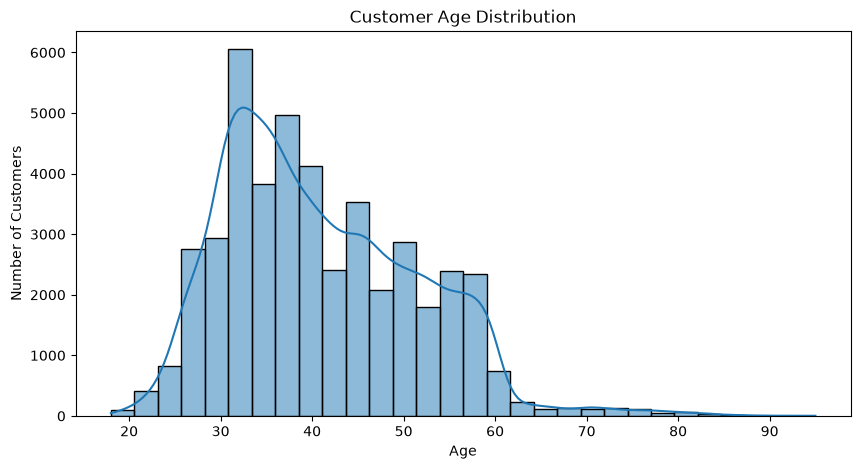

In [60]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_clean,
    x="age",
    bins=30,
    kde=True
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

In [61]:
age_conversion = (
    df_clean.groupby("age_group", observed=True)["conversion"]
    .mean()
    .mul(100)
    .round(2)
)

age_conversion

age_group
18-25    23.95
26-35    12.00
36-45     9.39
46-55     9.35
56-65    14.12
66+      42.61
Name: conversion, dtype: float64

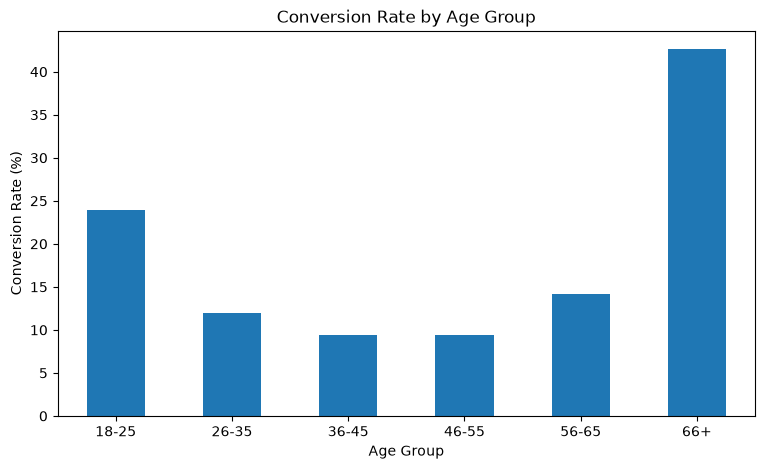

In [62]:
plt.figure(figsize=(9, 5))

age_conversion.plot(kind="bar")

plt.title("Conversion Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=0)

plt.show()

### Job-wise Conversion Analysis

In [63]:
job_analysis = (
    df_clean.groupby("job")
    .agg(
        Customers=("conversion", "count"),
        Conversions=("conversion", "sum"),
        Conversion_Rate=("conversion", "mean")
    )
    .reset_index()
)

job_analysis["Conversion_Rate"] = (
    job_analysis["Conversion_Rate"] * 100
).round(2)

job_analysis = job_analysis.sort_values(
    "Conversion_Rate",
    ascending=False
)

job_analysis

,job,Customers,Conversions,Conversion_Rate
8,student,938,269,28.68
5,retired,2264,516,22.79
10,unemployed,1303,202,15.50
4,management,9458,1301,13.76
0,admin.,5171,631,12.20
6,self-employed,1579,187,11.84
11,unknown,288,34,11.81
9,technician,7597,840,11.06
7,services,4154,369,8.88
3,housemaid,1240,109,8.79


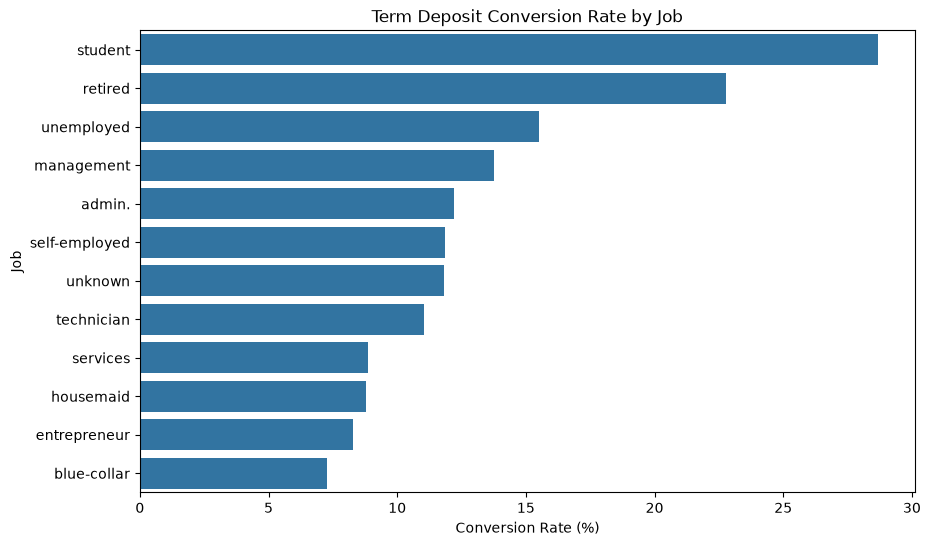

In [64]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=job_analysis,
    x="Conversion_Rate",
    y="job"
)

plt.title("Term Deposit Conversion Rate by Job")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Job")

plt.show()

### Education-wise Conversion

In [65]:
education_analysis = (
    df_clean.groupby("education")
    .agg(
        Customers=("conversion", "count"),
        Conversions=("conversion", "sum"),
        Conversion_Rate=("conversion", "mean")
    )
    .reset_index()
)

education_analysis["Conversion_Rate"] = (
    education_analysis["Conversion_Rate"] * 100
).round(2)

education_analysis.sort_values(
    "Conversion_Rate",
    ascending=False
)

,education,Customers,Conversions,Conversion_Rate
2,tertiary,13301,1996,15.01
3,unknown,1857,252,13.57
1,secondary,23202,2450,10.56
0,primary,6851,591,8.63


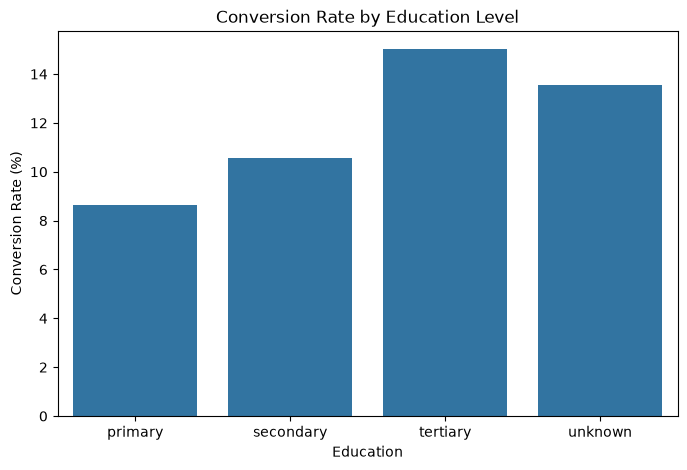

In [66]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=education_analysis,
    x="education",
    y="Conversion_Rate"
)

plt.title("Conversion Rate by Education Level")
plt.xlabel("Education")
plt.ylabel("Conversion Rate (%)")

plt.show()

### Contact Channel Analysis

In [67]:
contact_volume = (
    df_clean["contact"]
    .value_counts()
)

contact_volume

contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

In [68]:
contact_analysis = (
    df_clean.groupby("contact")
    .agg(
        Customers=("conversion", "count"),
        Conversions=("conversion", "sum"),
        Conversion_Rate=("conversion", "mean")
    )
    .reset_index()
)

contact_analysis["Conversion_Rate"] = (
    contact_analysis["Conversion_Rate"] * 100
).round(2)

contact_analysis.sort_values(
    "Conversion_Rate",
    ascending=False
)

,contact,Customers,Conversions,Conversion_Rate
0,cellular,29285,4369,14.92
1,telephone,2906,390,13.42
2,unknown,13020,530,4.07


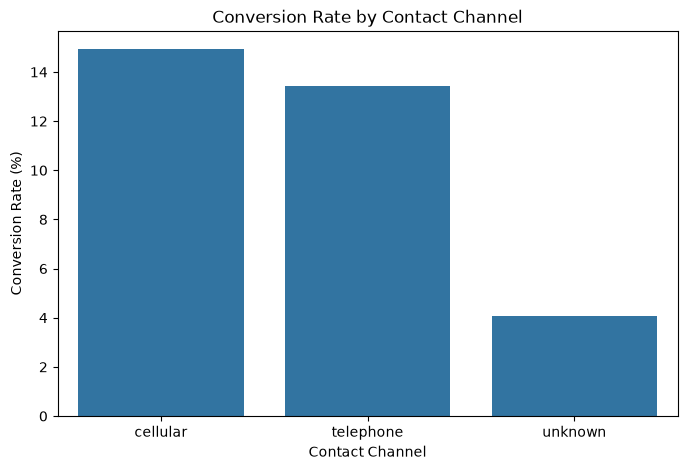

In [69]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=contact_analysis,
    x="contact",
    y="Conversion_Rate"
)

plt.title("Conversion Rate by Contact Channel")
plt.xlabel("Contact Channel")
plt.ylabel("Conversion Rate (%)")

plt.show()

### Campaign Contact Frequency

In [70]:
campaign_analysis = (
    df_clean.groupby("campaign_contact_group", observed=True)
    .agg(
        Customers=("conversion", "count"),
        Conversions=("conversion", "sum"),
        Conversion_Rate=("conversion", "mean")
    )
    .reset_index()
)

campaign_analysis["Conversion_Rate"] = (
    campaign_analysis["Conversion_Rate"] * 100
).round(2)

campaign_analysis

,campaign_contact_group,Customers,Conversions,Conversion_Rate
0,1 Contact,17544,2561,14.60
1,2 Contacts,12505,1401,11.20
2,3 Contacts,5521,618,11.19
3,4-5 Contacts,5286,456,8.63
4,6+ Contacts,4355,253,5.81


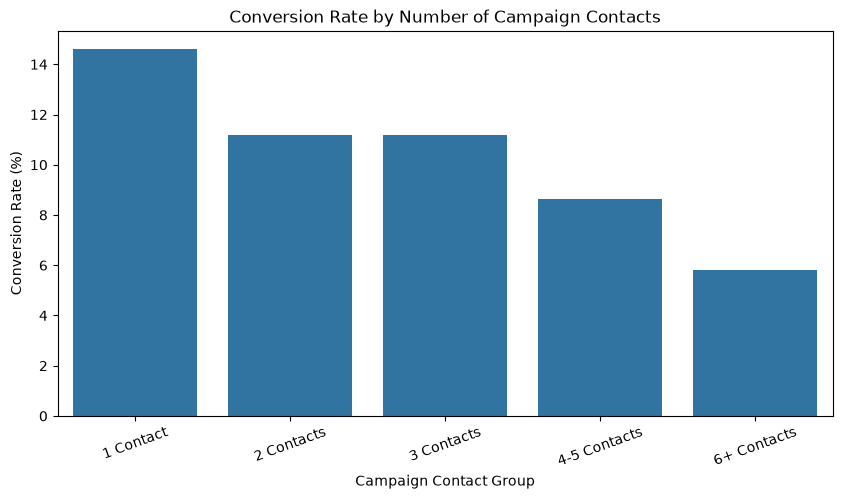

In [71]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=campaign_analysis,
    x="campaign_contact_group",
    y="Conversion_Rate"
)

plt.title("Conversion Rate by Number of Campaign Contacts")
plt.xlabel("Campaign Contact Group")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=20)

plt.show()

### Previous Campaign Analysis

In [72]:
previous_campaign_analysis = (
    df_clean.groupby("poutcome")
    .agg(
        Customers=("conversion", "count"),
        Conversions=("conversion", "sum"),
        Conversion_Rate=("conversion", "mean")
    )
    .reset_index()
)

previous_campaign_analysis["Conversion_Rate"] = (
    previous_campaign_analysis["Conversion_Rate"] * 100
).round(2)

previous_campaign_analysis.sort_values(
    "Conversion_Rate",
    ascending=False
)

,poutcome,Customers,Conversions,Conversion_Rate
2,success,1511,978,64.73
1,other,1840,307,16.68
0,failure,4901,618,12.61
3,unknown,36959,3386,9.16


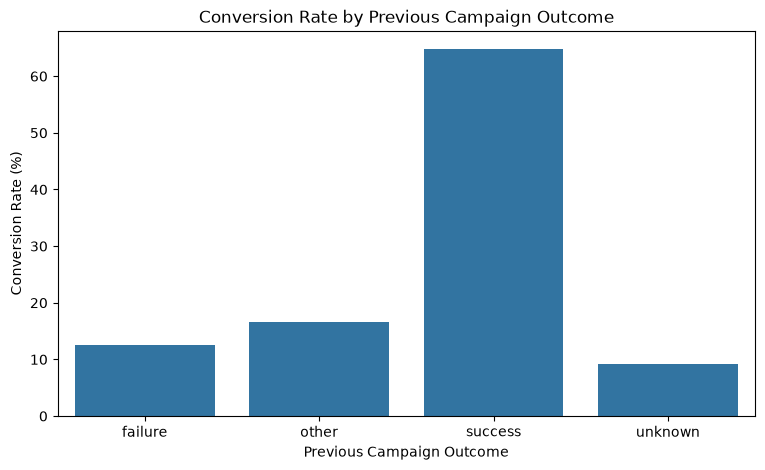

In [73]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=previous_campaign_analysis,
    x="poutcome",
    y="Conversion_Rate"
)

plt.title("Conversion Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Conversion Rate (%)")

plt.show()

### Previously Contacted vs New Customers

In [74]:
previous_contact_analysis = (
    df_clean.groupby("previously_contacted")
    .agg(
        Customers=("conversion", "count"),
        Conversions=("conversion", "sum"),
        Conversion_Rate=("conversion", "mean")
    )
    .reset_index()
)

previous_contact_analysis["Conversion_Rate"] = (
    previous_contact_analysis["Conversion_Rate"] * 100
).round(2)

previous_contact_analysis

,previously_contacted,Customers,Conversions,Conversion_Rate
0,No,36954,3384,9.16
1,Yes,8257,1905,23.07


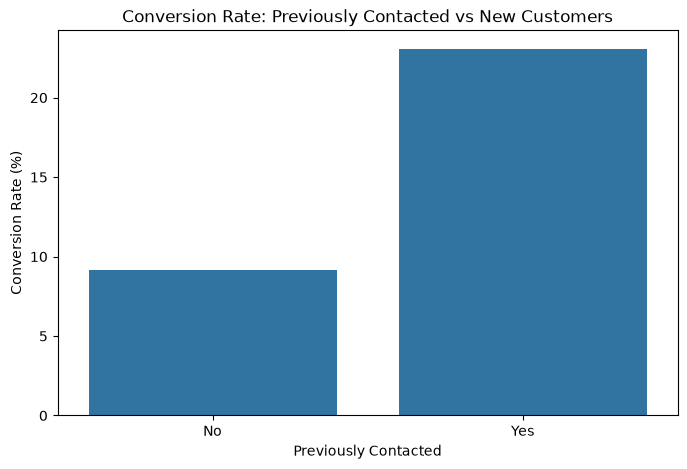

In [75]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=previous_contact_analysis,
    x="previously_contacted",
    y="Conversion_Rate"
)

plt.title("Conversion Rate: Previously Contacted vs New Customers")
plt.xlabel("Previously Contacted")
plt.ylabel("Conversion Rate (%)")

plt.show()

### Call Duration Analysis

In [76]:
duration_analysis = (
    df_clean.groupby("duration_group", observed=True)
    .agg(
        Customers=("conversion", "count"),
        Conversions=("conversion", "sum"),
        Conversion_Rate=("conversion", "mean")
    )
    .reset_index()
)

duration_analysis["Conversion_Rate"] = (
    duration_analysis["Conversion_Rate"] * 100
).round(2)

duration_analysis

,duration_group,Customers,Conversions,Conversion_Rate
0,<1 min,4766,9,0.19
1,1-3 min,17894,700,3.91
2,3-5 min,10277,1122,10.92
3,5-10 min,8484,1625,19.15
4,10+ min,3790,1833,48.36


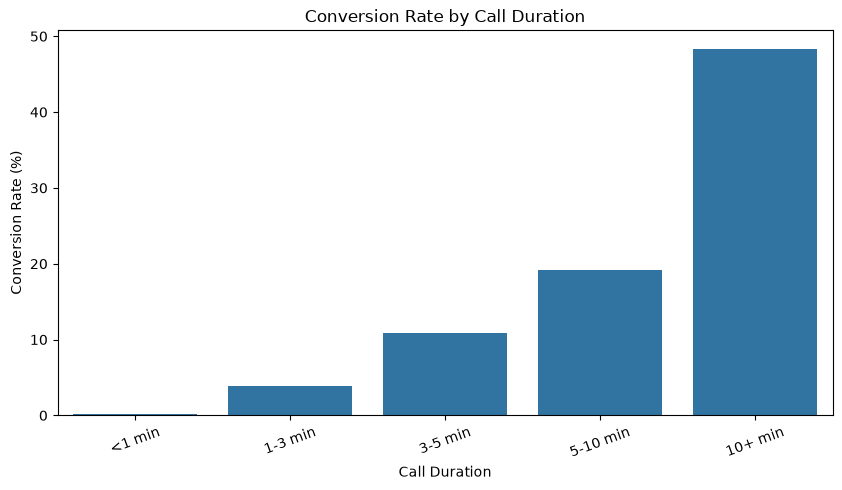

In [78]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=duration_analysis,
    x="duration_group",
    y="Conversion_Rate"
)

plt.title("Conversion Rate by Call Duration")
plt.xlabel("Call Duration")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=20)

plt.show()

### Loan Profile Analysis

In [79]:
loan_analysis = (
    df_clean.groupby("loan_profile")
    .agg(
        Customers=("conversion", "count"),
        Conversions=("conversion", "sum"),
        Conversion_Rate=("conversion", "mean")
    )
    .reset_index()
)

loan_analysis["Conversion_Rate"] = (
    loan_analysis["Conversion_Rate"] * 100
).round(2)

loan_analysis.sort_values(
    "Conversion_Rate",
    ascending=False
)

,loan_profile,Customers,Conversions,Conversion_Rate
2,No Loans,17204,3135,18.22
1,Housing Loan Only,20763,1670,8.04
3,Personal Loan Only,2877,219,7.61
0,Housing + Personal Loan,4367,265,6.07


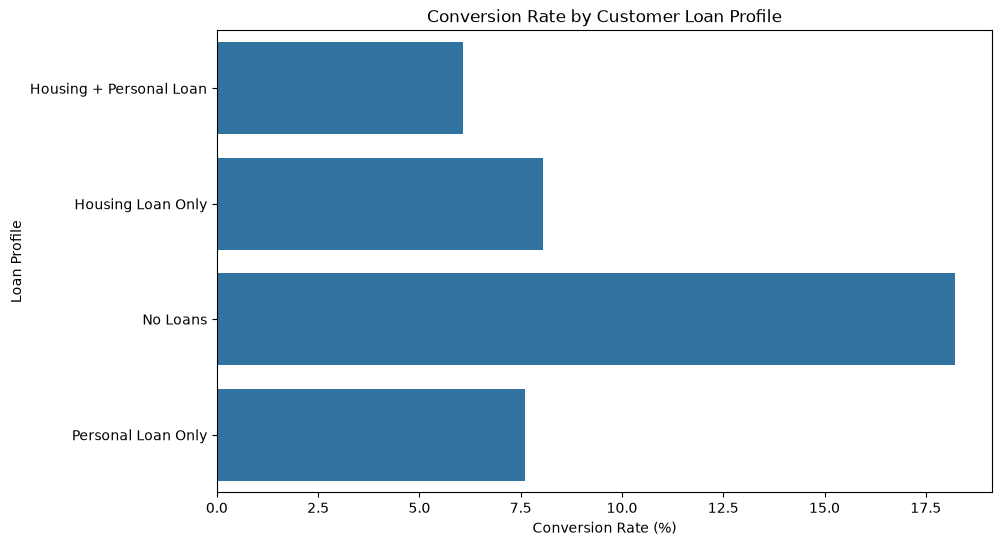

In [80]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=loan_analysis,
    x="Conversion_Rate",
    y="loan_profile"
)

plt.title("Conversion Rate by Customer Loan Profile")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Loan Profile")

plt.show()

### Housing Loan Analysis

In [81]:
housing_analysis = (
    df_clean.groupby("housing")["conversion"]
    .mean()
    .mul(100)
    .round(2)
)

housing_analysis

housing
no     16.7
yes     7.7
Name: conversion, dtype: float64

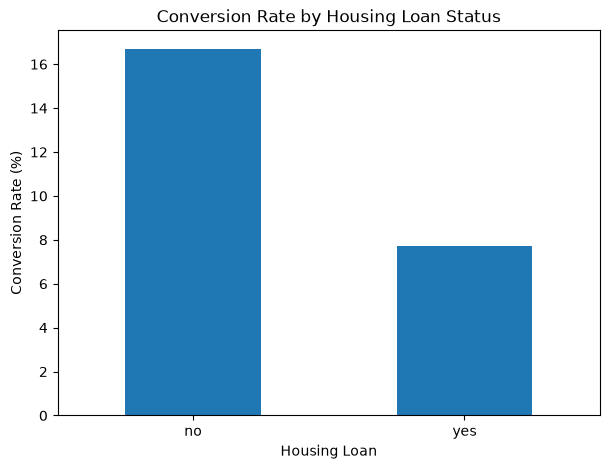

In [82]:
plt.figure(figsize=(7, 5))

housing_analysis.plot(kind="bar")

plt.title("Conversion Rate by Housing Loan Status")
plt.xlabel("Housing Loan")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=0)

plt.show()

### Personal Loan Analysis

In [83]:
personal_loan_analysis = (
    df_clean.groupby("loan")["conversion"]
    .mean()
    .mul(100)
    .round(2)
)

personal_loan_analysis

loan
no     12.66
yes     6.68
Name: conversion, dtype: float64

### Monthly Campaign Performance

In [84]:
month_order = [
    "jan",
    "feb",
    "mar",
    "apr",
    "may",
    "jun",
    "jul",
    "aug",
    "sep",
    "oct",
    "nov",
    "dec"
]

df_clean["month"] = pd.Categorical(
    df_clean["month"],
    categories=month_order,
    ordered=True
)

In [85]:
monthly_analysis = (
    df_clean.groupby("month", observed=True)
    .agg(
        Customers=("conversion", "count"),
        Conversions=("conversion", "sum"),
        Conversion_Rate=("conversion", "mean")
    )
    .reset_index()
)

monthly_analysis["Conversion_Rate"] = (
    monthly_analysis["Conversion_Rate"] * 100
).round(2)

monthly_analysis

,month,Customers,Conversions,Conversion_Rate
0,jan,1403,142,10.12
1,feb,2649,441,16.65
2,mar,477,248,51.99
3,apr,2932,577,19.68
4,may,13766,925,6.72
5,jun,5341,546,10.22
6,jul,6895,627,9.09
7,aug,6247,688,11.01
8,sep,579,269,46.46
9,oct,738,323,43.77


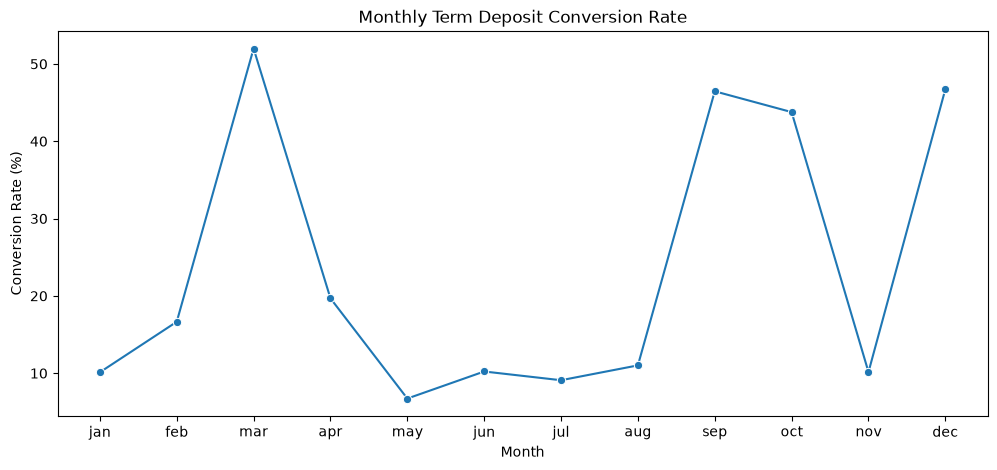

In [86]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_analysis,
    x="month",
    y="Conversion_Rate",
    marker="o"
)

plt.title("Monthly Term Deposit Conversion Rate")
plt.xlabel("Month")
plt.ylabel("Conversion Rate (%)")

plt.show()

### Conversion by Marital Status

In [87]:
marital_analysis = (
    df_clean.groupby("marital")
    .agg(
        Customers=("conversion", "count"),
        Conversions=("conversion", "sum"),
        Conversion_Rate=("conversion", "mean")
    )
    .reset_index()
)

marital_analysis["Conversion_Rate"] = (
    marital_analysis["Conversion_Rate"] * 100
).round(2)

marital_analysis

,marital,Customers,Conversions,Conversion_Rate
0,divorced,5207,622,11.95
1,married,27214,2755,10.12
2,single,12790,1912,14.95


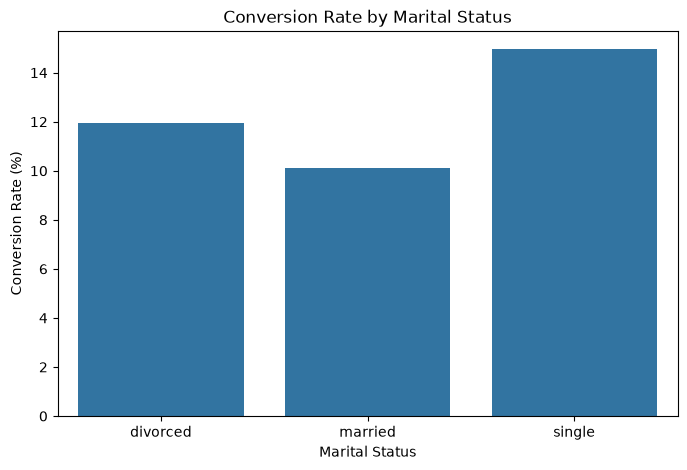

In [88]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=marital_analysis,
    x="marital",
    y="Conversion_Rate"
)

plt.title("Conversion Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Conversion Rate (%)")

plt.show()

## 4.Advanced Conversion & Funnel Analysis

In [99]:
total_contacts = len(df_clean)
total_conversions = df_clean["conversion"].sum()
total_non_conversions = total_contacts - total_conversions

overall_conversion_rate = (
    total_conversions / total_contacts
) * 100

overall_dropoff_rate = (
    total_non_conversions / total_contacts
) * 100

kpi_table = pd.DataFrame({
    "Metric": [
        "Total Customers Contacted",
        "Successful Conversions",
        "Non-Conversions",
        "Conversion Rate",
        "Drop-off Rate"
    ],
    "Value": [
        total_contacts,
        total_conversions,
        total_non_conversions,
        round(overall_conversion_rate, 2),
        round(overall_dropoff_rate, 2)
    ]
})

kpi_table

,Metric,Value
0,Total Customers Contacted,45211.0
1,Successful Conversions,5289.0
2,Non-Conversions,39922.0
3,Conversion Rate,11.7
4,Drop-off Rate,88.3


In [100]:
channel_performance = (
    df_clean.groupby("contact")
    .agg(
        Customers=("conversion", "count"),
        Conversions=("conversion", "sum"),
        Conversion_Rate=("conversion", "mean")
    )
    .reset_index()
)

channel_performance["Conversion_Rate"] = (
    channel_performance["Conversion_Rate"] * 100
).round(2)

channel_performance = channel_performance.sort_values(
    "Conversion_Rate",
    ascending=False
)

channel_performance

,contact,Customers,Conversions,Conversion_Rate
0,cellular,29285,4369,14.92
1,telephone,2906,390,13.42
2,unknown,13020,530,4.07


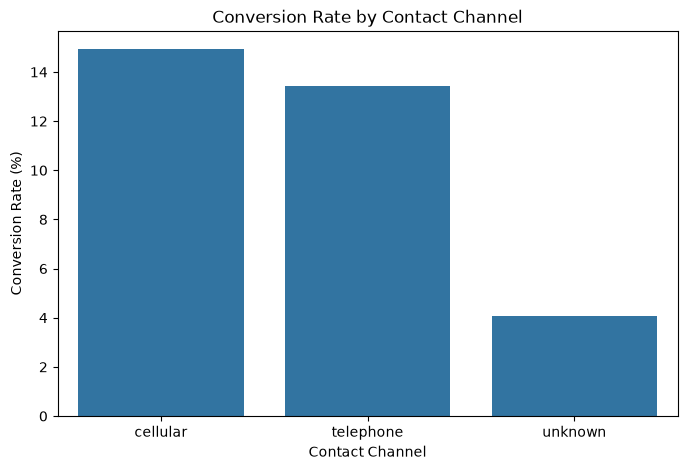

In [101]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=channel_performance,
    x="contact",
    y="Conversion_Rate"
)

plt.title("Conversion Rate by Contact Channel")
plt.xlabel("Contact Channel")
plt.ylabel("Conversion Rate (%)")

plt.show()

### Campaign contact performance

In [102]:
campaign_performance = (
    df_clean.groupby("campaign_contact_group", observed=True)
    .agg(
        Customers=("conversion", "count"),
        Conversions=("conversion", "sum"),
        Conversion_Rate=("conversion", "mean")
    )
    .reset_index()
)

campaign_performance["Conversion_Rate"] = (
    campaign_performance["Conversion_Rate"] * 100
).round(2)

campaign_performance

,campaign_contact_group,Customers,Conversions,Conversion_Rate
0,1 Contact,17544,2561,14.60
1,2 Contacts,12505,1401,11.20
2,3 Contacts,5521,618,11.19
3,4-5 Contacts,5286,456,8.63
4,6+ Contacts,4355,253,5.81


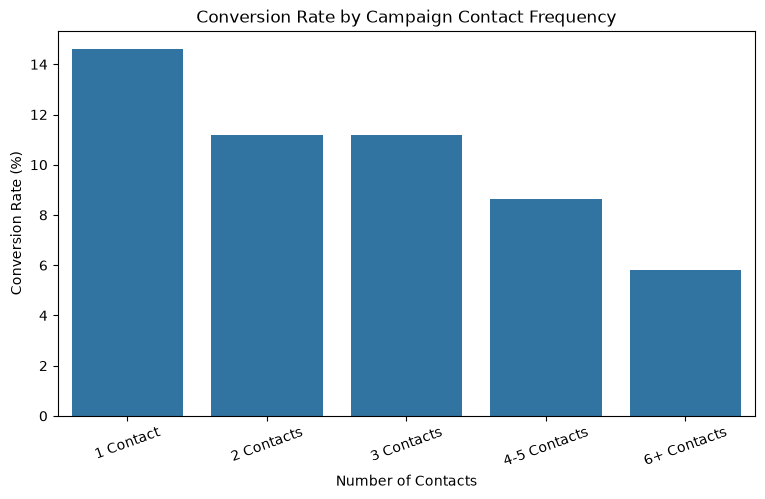

In [103]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=campaign_performance,
    x="campaign_contact_group",
    y="Conversion_Rate"
)

plt.title("Conversion Rate by Campaign Contact Frequency")
plt.xlabel("Number of Contacts")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=20)

plt.show()

### Customer segment performance

In [104]:
age_performance = (
    df_clean.groupby("age_group", observed=True)
    .agg(
        Customers=("conversion", "count"),
        Conversions=("conversion", "sum"),
        Conversion_Rate=("conversion", "mean")
    )
    .reset_index()
)

age_performance["Conversion_Rate"] = (
    age_performance["Conversion_Rate"] * 100
).round(2)

age_performance

,age_group,Customers,Conversions,Conversion_Rate
0,18-25,1336,320,23.95
1,26-35,15571,1869,12.00
2,36-45,13856,1301,9.39
3,46-55,9548,893,9.35
4,56-65,4149,586,14.12
5,66+,751,320,42.61


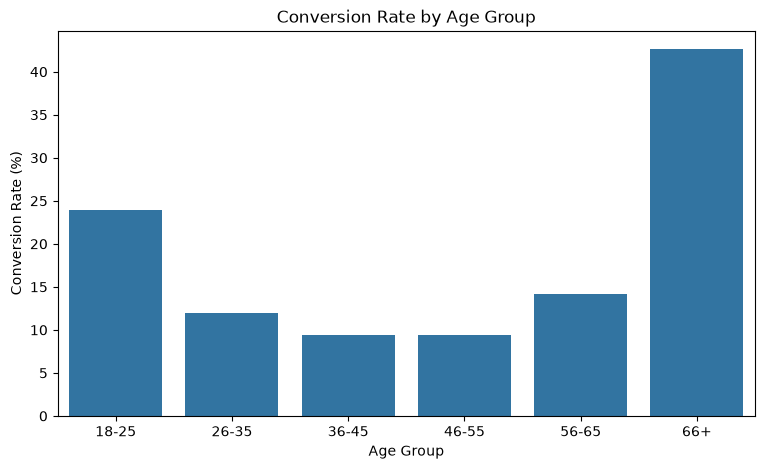

In [105]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=age_performance,
    x="age_group",
    y="Conversion_Rate"
)

plt.title("Conversion Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Conversion Rate (%)")

plt.show()

### Monthly conversion performance

In [106]:
monthly_performance = (
    df_clean.groupby("month", observed=True)
    .agg(
        Customers=("conversion", "count"),
        Conversions=("conversion", "sum"),
        Conversion_Rate=("conversion", "mean")
    )
    .reset_index()
)

monthly_performance["Conversion_Rate"] = (
    monthly_performance["Conversion_Rate"] * 100
).round(2)

monthly_performance

,month,Customers,Conversions,Conversion_Rate
0,jan,1403,142,10.12
1,feb,2649,441,16.65
2,mar,477,248,51.99
3,apr,2932,577,19.68
4,may,13766,925,6.72
5,jun,5341,546,10.22
6,jul,6895,627,9.09
7,aug,6247,688,11.01
8,sep,579,269,46.46
9,oct,738,323,43.77


### Monthly conversion performance

In [107]:
monthly_performance = (
    df_clean.groupby("month", observed=True)
    .agg(
        Customers=("conversion", "count"),
        Conversions=("conversion", "sum"),
        Conversion_Rate=("conversion", "mean")
    )
    .reset_index()
)

monthly_performance["Conversion_Rate"] = (
    monthly_performance["Conversion_Rate"] * 100
).round(2)

monthly_performance

,month,Customers,Conversions,Conversion_Rate
0,jan,1403,142,10.12
1,feb,2649,441,16.65
2,mar,477,248,51.99
3,apr,2932,577,19.68
4,may,13766,925,6.72
5,jun,5341,546,10.22
6,jul,6895,627,9.09
7,aug,6247,688,11.01
8,sep,579,269,46.46
9,oct,738,323,43.77


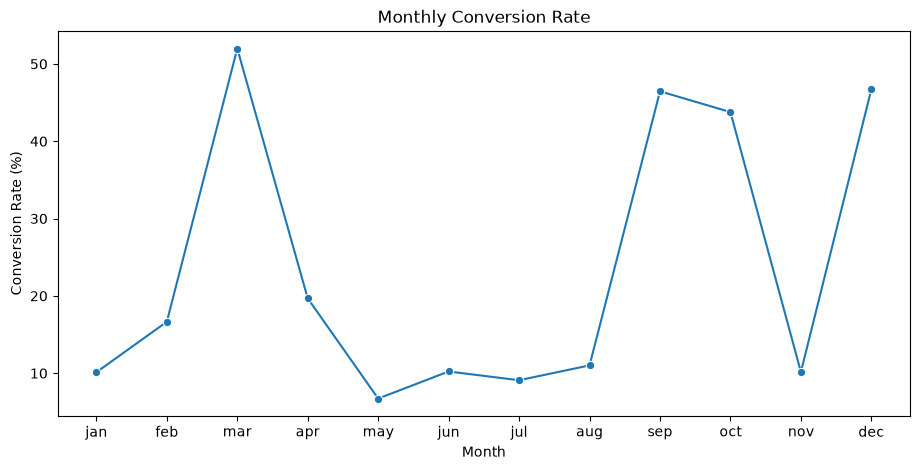

In [108]:
plt.figure(figsize=(11, 5))

sns.lineplot(
    data=monthly_performance,
    x="month",
    y="Conversion_Rate",
    marker="o"
)

plt.title("Monthly Conversion Rate")
plt.xlabel("Month")
plt.ylabel("Conversion Rate (%)")

plt.show()

In [109]:
print(f"Overall Conversion Rate: {overall_conversion_rate:.2f}%")
print(f"Overall Drop-off Rate: {overall_dropoff_rate:.2f}%")

Overall Conversion Rate: 11.70%
Overall Drop-off Rate: 88.30%


### Find best and worst channels

In [110]:
best_channel = channel_performance.iloc[0]
worst_channel = channel_performance.iloc[-1]

print(
    f"Best channel: {best_channel['contact']} "
    f"({best_channel['Conversion_Rate']:.2f}%)"
)

print(
    f"Lowest-performing channel: {worst_channel['contact']} "
    f"({worst_channel['Conversion_Rate']:.2f}%)"
)

Best channel: cellular (14.92%)
Lowest-performing channel: unknown (4.07%)


### Find best and worst age groups

In [111]:
best_age = age_performance.iloc[
    age_performance["Conversion_Rate"].argmax()
]

worst_age = age_performance.iloc[
    age_performance["Conversion_Rate"].argmin()
]

print(
    f"Highest-converting age group: "
    f"{best_age['age_group']} "
    f"({best_age['Conversion_Rate']:.2f}%)"
)

print(
    f"Lowest-converting age group: "
    f"{worst_age['age_group']} "
    f"({worst_age['Conversion_Rate']:.2f}%)"
)

Highest-converting age group: 66+ (42.61%)
Lowest-converting age group: 46-55 (9.35%)


In [112]:
best_campaign = campaign_performance.iloc[0]

print(
    f"Highest-converting campaign contact group: "
    f"{best_campaign['campaign_contact_group']} "
    f"({best_campaign['Conversion_Rate']:.2f}%)"
)

Highest-converting campaign contact group: 1 Contact (14.60%)
